In [370]:
## IMPORTS
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.animation import FuncAnimation
import numpy as np
import scipy as sp

from kwave.kgrid import kWaveGrid
from kwave.kmedium import kWaveMedium
from kwave.ksensor import kSensor
from kwave.ksource import kSource
from kwave.kspaceFirstOrder2D import kspaceFirstOrder2D
from kwave.utils.signals import tone_burst
from kwave.kWaveSimulation import SimulationOptions
from kwave.options.simulation_execution_options import SimulationExecutionOptions
from kwave.utils.colormap import get_color_map

In [371]:
## SIMULATION SETUP
c0 = 1540                       # [m/s] Speed of sound
rho0 = 1000                     # [kg/m^3] Density of water
source_f0 = 1e6                 # [Hz] Source frequency
source_amp = 1e6                # [Pa] Source amplitude
source_cycles = 2               # Number of cycles in the pulse

grid_size_x = 40e-3             # [m] Grid size in x (NB: Depth in k-Wave)
grid_size_y = 40e-3             # [m] Grid size in z (NB: Width in k-Wave)
ppw = 5                         # Points per wavelength
cfl = 0.1                       # Related to the time resolution, lower is more accurate (no need to change)

viz_t = grid_size_y / 2 / c0 * 0.75      # Visualization time [s]

aperture = 2*1e-2                 # 0.02 m -  2 cm

focal_point_distance = 3*1e-2     # 0.03 m - 2 cm

In [372]:
# GRID SETUP
dx = c0 / (ppw * source_f0)     # Grid resolution
Nx = round(grid_size_x / dx)    # Number of grid points in x, NB: This is depth
Ny = round(grid_size_y / dx)    # Number of grid points in y, NB: This is width (lateral)
kgrid = kWaveGrid([Nx, Ny], [dx, dx])
kgrid.makeTime(c0, cfl);         # Make time array based on the Courant-Friedrichs-Lewy (CFL) condition

numb_indices_aperture = round(aperture/dx)
indices_focal_point = round(focal_point_distance/dx)

0.03


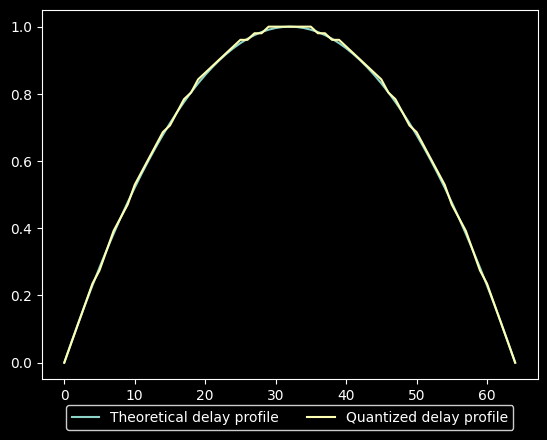

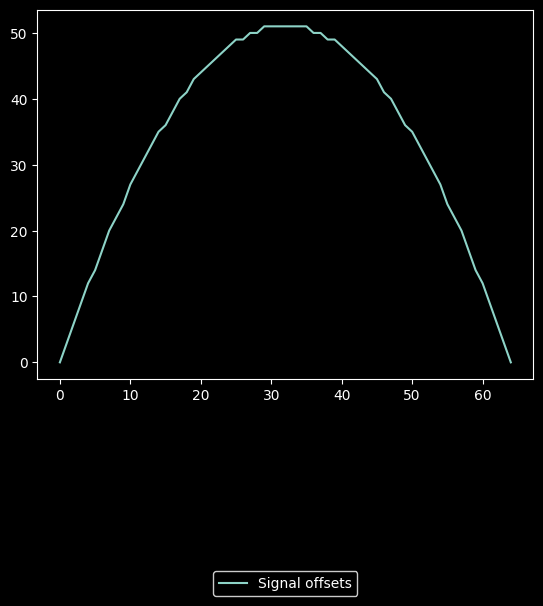

In [373]:
# DELAY PROFILE

class Point:
    def __init__(self,x,y,z):
        self.x = x
        self.y = y
        self.z = z

center_element = Point(round(Nx//2)*dx,0,0)
focal_point = Point(round(Nx//2)*dx,focal_point_distance,0)


def distance(point1: Point, point2: Point):
    return np.sqrt(((point1.x - point2.x)**2)+((point1.y - point2.y)**2)+((point1.z - point2.z)**2))

rc = distance(center_element, focal_point)                                                          
print(rc)
def timeDelay(rc, ri):
    return (1/c0)*(rc-ri)


timeDelays = [0]                                                           # Initialize empty timeDelay list

for i in range(1, numb_indices_aperture//2 + 1):                           # Calculate time delays
    element_i = Point(center_element.x+(i*dx), 0, 0)
    #print(element_i.x)
    timeDelays.append(timeDelay(rc, distance(element_i,focal_point)))

timeDelays = timeDelays[::-1][:-1] + timeDelays                            # Mirror all elemnts right of 0 to left side in reverse order

for i in range(len(timeDelays)//2):                                        # If all true - mapping correct if focal point is at center
    if timeDelays[i] != timeDelays[-1-i]:
        print('Time delays not symmetric!')
        break

timeDelays = np.array(timeDelays)
timeDelats_copy = timeDelays

def shift(delays: np.ndarray , temp_sampling_frequency: float) -> np.ndarray:
    return np.round((delays*temp_sampling_frequency)).astype(int)


min_delay = timeDelays.min()
timeDelays = timeDelays - min_delay
delayMap = shift(timeDelays,(1/kgrid.dt))

min_timeDelays = timeDelays.min()
time_delay_temp = timeDelays - min_timeDelays

timeDelays_normalized = time_delay_temp / max(time_delay_temp)
delayMap_normalized = delayMap / max(delayMap)


fig = plt.figure()
ax = plt.subplot()
ax.plot(timeDelays_normalized, label="Theoretical delay profile")
ax.plot(delayMap_normalized, label='Quantized delay profile')
ax.legend(loc = 'upper center', bbox_to_anchor=(0.5, -0.05),fancybox=True, shadow=True, ncols = 3)
plt.show()

fig = plt.figure()
ax = plt.subplot()
ax.plot(delayMap, label="Signal offsets")
ax.legend(loc = 'upper center', bbox_to_anchor=(0.5, -0.5), fancybox = True, shadow= True, ncols = 1)
plt.show()

In [374]:
print(f'Ended up with sampling frequency = {round(1/kgrid.dt)} Hz and clf = {cfl}')

Ended up with sampling frequency = 50000000 Hz and clf = 0.1


It matches pretty well when scaled. You can clearly see the effects from the quantization and that the timedelays are offset in integers. Decreasing cfl makes it better, however its clear from cfl=0.3 that it fits well. 

In [375]:
## SETUP AND RUN SIMULATION
def __altSign__(i) -> int: #gives every other negative as well as keeping the splitting i evenly around 0 
    cut = i // 2
    return -cut if i % 2 == 0 else cut + 1


# SOURCE SETUP
def run_setup(delayMap, Triangwindow: bool = False):
    # Source signal, Gaussian pulse
    global source_amp
    if Triangwindow:
        source_amp = source_amp*np.expand_dims(sp.signal.windows.triang(len(delayMap)),1)   
    
    source_sig = source_amp * tone_burst(1 / kgrid.dt, source_f0, source_cycles, signal_offset = delayMap)

    # Define kWave source object
    source = kSource()
    source.p_mask = np.zeros_like(kgrid.x)

    x_center = int(center_element.x/dx)

    x_start = x_center - round(numb_indices_aperture/2)
    
    source.p_mask[x_start : x_start + numb_indices_aperture , 0] = 1

    source.p = source_sig

    # Setup sensor
    sensor = kSensor(record=['p', 'p_max'])                     # Sensor object, record pressure and maximum pressure
    sensor.mask = np.ones_like(kgrid.x)                    # Sensor mask, all grid points 

    # Setup medium
    medium = kWaveMedium(sound_speed=c0, density=rho0)          # Define medium object, simple homogeneous medium
    return source, sensor, medium

source, sensor, medium = run_setup(delayMap)


In [376]:
# Setup simulation options
def run_simulation():
    simulation_options = SimulationOptions(
        pml_auto=True,
        pml_inside=False,
        save_to_disk=True,
        data_cast='single',
    )
    execution_options = SimulationExecutionOptions(is_gpu_simulation=False, num_threads=1)

    return kspaceFirstOrder2D(
        kgrid=kgrid,
        medium=medium,
        source=source,
        sensor=sensor,
        simulation_options=simulation_options,
        execution_options=execution_options,
    )

sensor_data = run_simulation()

┌───────────────────────────────────────────────────────────────┐
│                   kspaceFirstOrder-OMP v1.3                   │
├───────────────────────────────────────────────────────────────┤
│ Reading simulation configuration:                        Done │
│ Number of CPU threads:                                      1 │
│ Processor name:                                               │
├───────────────────────────────────────────────────────────────┤
│                      Simulation details                       │
├───────────────────────────────────────────────────────────────┤
│ Domain dimensions:                                  162 x 162 │
│ Medium type:                                               2D │
│ Simulation time steps:                                   1839 │
├───────────────────────────────────────────────────────────────┤
│                        Initialization                         │
├───────────────────────────────────────────────────────────────┤
│ Memory a

In [377]:
# Extract pressure field from
p_field = np.reshape(sensor_data["p"], (kgrid.Nt, Nx, Ny), order="F")   # Stored in Fortran ordering for some reason
p_max_field = np.reshape(sensor_data['p_max'], (Nx, Ny), order="F")

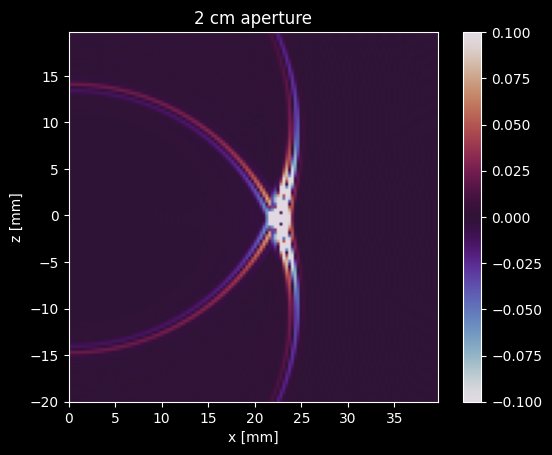

In [378]:
## VISUALIZATION
plt.style.use('dark_background')

# Get frame number to plot
N_frame = np.round(np.where(kgrid.t_array[0] > viz_t)[0][0]).astype(int)   # Number of frames to visualize

# Normalize frames based on the maximum value over all frames
max_value = np.max(np.abs(p_field))
p_plot = p_field / max_value

cmap = 'twilight'
extent = np.array([kgrid.y_vec[0]+20e-3, kgrid.y_vec[-1]+20e-3, kgrid.x_vec[0], kgrid.x_vec[-1]])*1e3

# Create a figure and axis
fig, ax = plt.subplots()
image = ax.imshow(p_plot[N_frame+350], cmap=cmap, extent=extent, vmin=-0.1, vmax=0.1)
fig.colorbar(image, ax=ax)
plt.xlabel('x [mm]')
plt.ylabel('z [mm]')
plt.title('2 cm aperture')
plt.show()


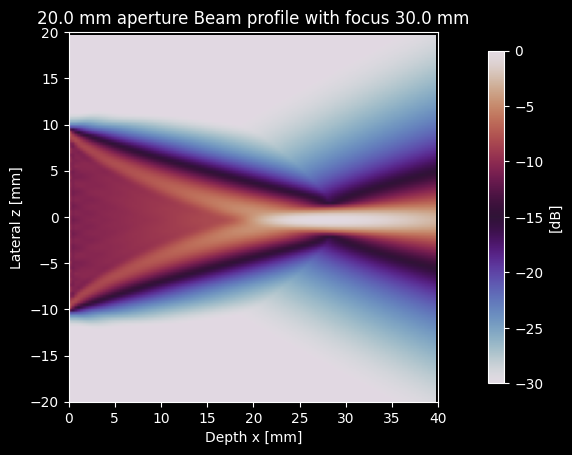

In [379]:
# Beam profile

p_max = np.abs(p_max_field)
p_max /= np.max(p_max)
p_max_db = 20*np.log10(p_max)

plt.figure()

im1 = plt.imshow((p_max_db), cmap=cmap, vmin=-30, vmax=0, extent=extent)

plt.title(f'{aperture*1e3} mm aperture Beam profile with focus {focal_point_distance*1e3} mm')
plt.xlabel("Depth x [mm]")
plt.ylabel("Lateral z [mm]")
plt.xlim(0,40)
plt.ylim(-20,20)
plt.colorbar(im1, pad=0.1, shrink=0.9, label="[dB]")
plt.show()
    

/var/folders/j8/1f5hbmds4rx5frb7zgfcxbwh0000gn/T/ipykernel_46248/3662476249.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


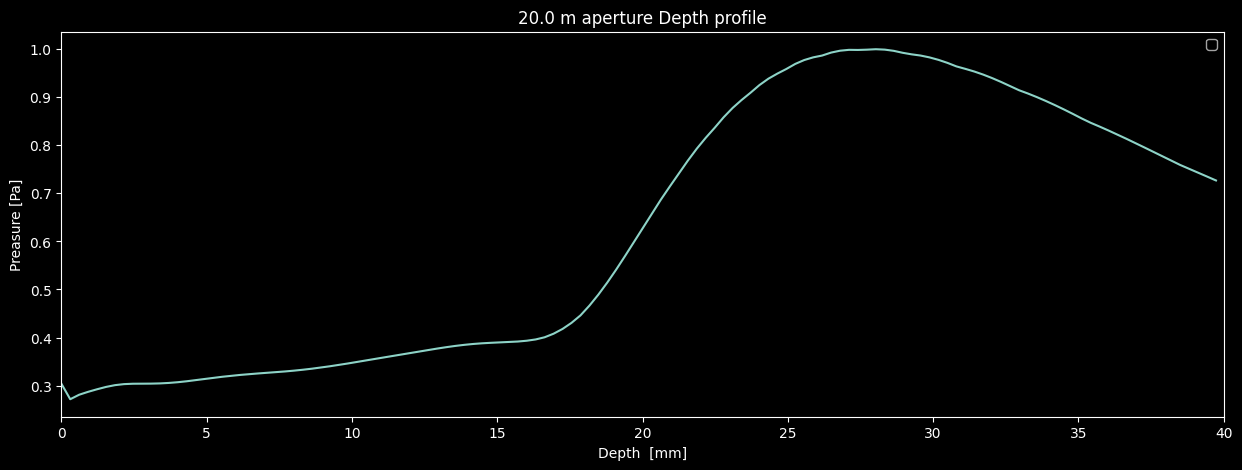

In [380]:
# Distance to maximum pressure
x_mm = (kgrid.x_vec - kgrid.x_vec[0])*1e3 


plt.figure(figsize=(15,5))
plt.style.use('dark_background')
plt.plot(x_mm, p_max[round(Nx/2), :])

#plt.vlines(y_other, row.min(), row.max(), colors='r', linestyles='dashed', label='Estimate')

#plt.vlines(y, row.min(), peak, colors='g', linestyles='dashed', label='Bla')

plt.title(f'{aperture*1e3} m aperture Depth profile')
plt.xlabel("Depth  [mm]")
plt.ylabel("Preasure [Pa]")
plt.legend()
plt.xlim(0,40)
plt.show()
    

The preasure hits well, but the peak is not at the focal point, but close to! In comparison to unfocused, it changes where the peak happens as well as how quickly it changes to peak power

In [381]:
# Steering implementation - steering, flip, shift

def steering(angle, x_end, x_el):
    return (1/c0)*np.tan(angle)*(x_el - x_end)

angle = np.deg2rad(10)
end_element = Point(round(Ny/2)+round(numb_indices_aperture/2), 0, 0)
x_end = end_element.x * dx
steered_delays = []

for i in range(0, numb_indices_aperture):
    element_i = Point((round(Ny/2)-round(numb_indices_aperture/2))*dx+(i*dx), 0, 0)
    #print(element_i.x)
    steered_delays.append(steering(angle, x_end, element_i.x))

def flip(array: np.array) -> np.array:
    min_delay = array.min()
    return array - min_delay

steered_delays = np.array(steered_delays)
steered_delays = flip(steered_delays)

delayMap = shift(timeDelays,(1/kgrid.dt)) + shift(steered_delays,(1/kgrid.dt))



In [382]:
# New simulation

## SETUP AND RUN SIMULATION

# SOURCE SETUP

# Source signal, Gaussian pulse
source_sig = source_amp * tone_burst(1 / kgrid.dt, source_f0, source_cycles, signal_offset = delayMap)


# Define kWave source object
source = kSource()
source.p_mask = np.zeros_like(kgrid.x)

for i in range(numb_indices_aperture):
    def __altSign__(i) -> int: #gives every other negative as well as keeping the splitting i evenly around 0 
        cut = i // 2
        return -cut if i % 2 == 0 else cut + 1

    source.p_mask[round(center_element.x/dx)+__altSign__(i), 0] = 1
source.p = source_sig                                       # Source signal (pressure source)

# Setup sensor
sensor = kSensor(record=['p', 'p_max'])                     # Sensor object, record pressure and maximum pressure
sensor.mask = np.ones_like(kgrid.x)                    # Sensor mask, all grid points 

# Setup medium
medium = kWaveMedium(sound_speed=c0, density=rho0)          # Define medium object, simple homogeneous medium


In [383]:
# Setup simulation options
simulation_options = SimulationOptions(
    pml_auto=True,
    pml_inside=False,
    save_to_disk=True,
    data_cast='single',
)
execution_options = SimulationExecutionOptions(is_gpu_simulation=False, num_threads=1)

# Run 2D simulation (to save some time)
sensor_data = kspaceFirstOrder2D(kgrid=kgrid, medium=medium, source=source, sensor=sensor, simulation_options=simulation_options, execution_options=execution_options)

┌───────────────────────────────────────────────────────────────┐
│                   kspaceFirstOrder-OMP v1.3                   │
├───────────────────────────────────────────────────────────────┤
│ Reading simulation configuration:                        Done │
│ Number of CPU threads:                                      1 │
│ Processor name:                                               │
├───────────────────────────────────────────────────────────────┤
│                      Simulation details                       │
├───────────────────────────────────────────────────────────────┤
│ Domain dimensions:                                  162 x 162 │
│ Medium type:                                               2D │
│ Simulation time steps:                                   1839 │
├───────────────────────────────────────────────────────────────┤
│                        Initialization                         │
├───────────────────────────────────────────────────────────────┤
│ Memory a

In [384]:
# Extract pressure field from
p_field = np.reshape(sensor_data["p"], (kgrid.Nt, Nx, Ny), order="F")   # Stored in Fortran ordering for some reason
p_max_field = np.reshape(sensor_data['p_max'], (Nx, Ny), order="F")

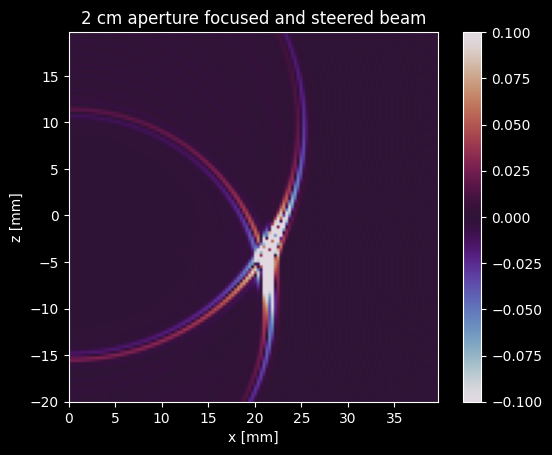

In [385]:
## VISUALIZATION
plt.style.use('dark_background')

# Get frame number to plot
N_frame = np.round(np.where(kgrid.t_array[0] > viz_t)[0][0]).astype(int)   # Number of frames to visualize

# Normalize frames based on the maximum value over all frames
max_value = np.max(np.abs(p_field))
p_plot = p_field / max_value

cmap = 'twilight'
extent = np.array([kgrid.y_vec[0]+20e-3, kgrid.y_vec[-1]+20e-3, kgrid.x_vec[0], kgrid.x_vec[-1]])*1e3

# Create a figure and axis
fig, ax = plt.subplots()
image = ax.imshow(p_plot[N_frame+375], cmap=cmap, extent=extent, vmin=-0.1, vmax=0.1)
fig.colorbar(image, ax=ax)
plt.xlabel('x [mm]')
plt.ylabel('z [mm]')
plt.title('2 cm aperture focused and steered beam')
plt.show()



In [386]:
# Helper functions
wavelength = lambda f0,c0: c0/f0
theoretical_beam_profile = lambda x,z: np.sinc(aperture*x/wavelength(source_f0,c0)*z)
in_dB = lambda el: 20*np.log10(np.maximum(el, 1e-18)) 


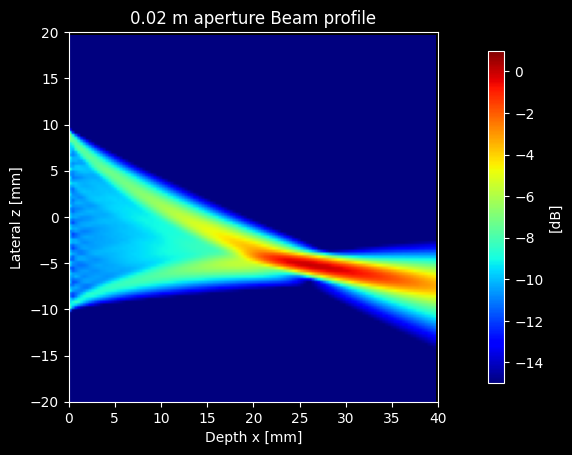

In [387]:
# Beam profile
plt.style.use('dark_background')

# Normalize frames based on the maximum value over all frames
p_max = np.abs(p_max_field)
p_max /= np.max(p_max)
p_max_db = in_dB(p_max)

cmap = 'jet'

plt.figure()

im1 = plt.imshow(p_max_db, cmap=cmap, vmin=-15, vmax=1, extent=extent)

plt.title(f'{aperture} m aperture Beam profile')
plt.xlabel("Depth x [mm]")
plt.ylabel("Lateral z [mm]")
plt.xlim(0,40)
plt.ylim(-20,20)
plt.colorbar(im1, pad=0.1, shrink=0.9, label="[dB]")
plt.show()

In [388]:
source_cycles = 100
delayMap = shift(timeDelays,(1/kgrid.dt))
source, sensor, medium = run_setup(delayMap)
sensor_data = run_simulation()


┌───────────────────────────────────────────────────────────────┐
│                   kspaceFirstOrder-OMP v1.3                   │
├───────────────────────────────────────────────────────────────┤
│ Reading simulation configuration:                        Done │
│ Number of CPU threads:                                      1 │
│ Processor name:                                               │
├───────────────────────────────────────────────────────────────┤
│                      Simulation details                       │
├───────────────────────────────────────────────────────────────┤
│ Domain dimensions:                                  162 x 162 │
│ Medium type:                                               2D │
│ Simulation time steps:                                   1839 │
├───────────────────────────────────────────────────────────────┤
│                        Initialization                         │
├───────────────────────────────────────────────────────────────┤
│ Memory a

In [389]:
p_field = np.reshape(sensor_data["p"], (kgrid.Nt, Nx, Ny), order="F")   # Stored in Fortran ordering for some reason
p_max_field = np.reshape(sensor_data['p_max'], (Nx, Ny), order="F")

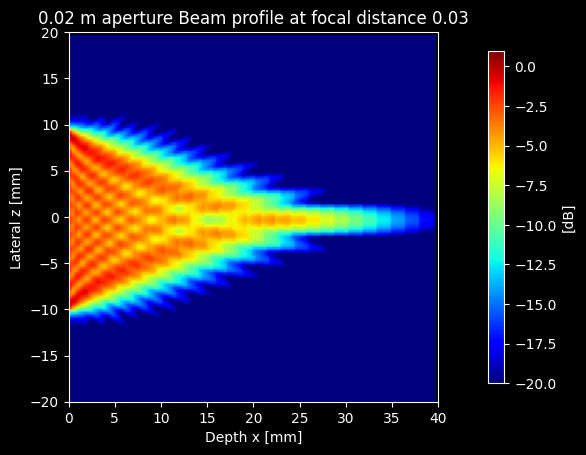

In [390]:
# Normalize frames based on the maximum value over all frames
p_max = np.abs(p_max_field)
p_max /= np.max(p_max)
p_max_db = in_dB(p_max)

cmap = 'jet'

plt.figure()
im1 = plt.imshow(p_max_db, cmap=cmap, vmin=-20, vmax=1, extent=extent)
plt.title(f'{aperture} m aperture Beam profile at focal distance {focal_point_distance}')
plt.xlabel("Depth x [mm]")
plt.ylabel("Lateral z [mm]")
plt.xlim(0,40)
plt.ylim(-20,20)
plt.colorbar(im1, pad=0.1, shrink=0.9, label="[dB]")
plt.show()

In [391]:
given_depth = focal_point_distance

beam_profile_p = p_max_db[:, round(given_depth/dx)]
beam_profile_p -= np.max(beam_profile_p)
x_mm = kgrid.x_vec[:]*1e3

beam_profile_t = theoretical_beam_profile(x_mm, given_depth)
theoretical_beam_profile_dB = in_dB(beam_profile_t)

<Figure size 640x480 with 0 Axes>

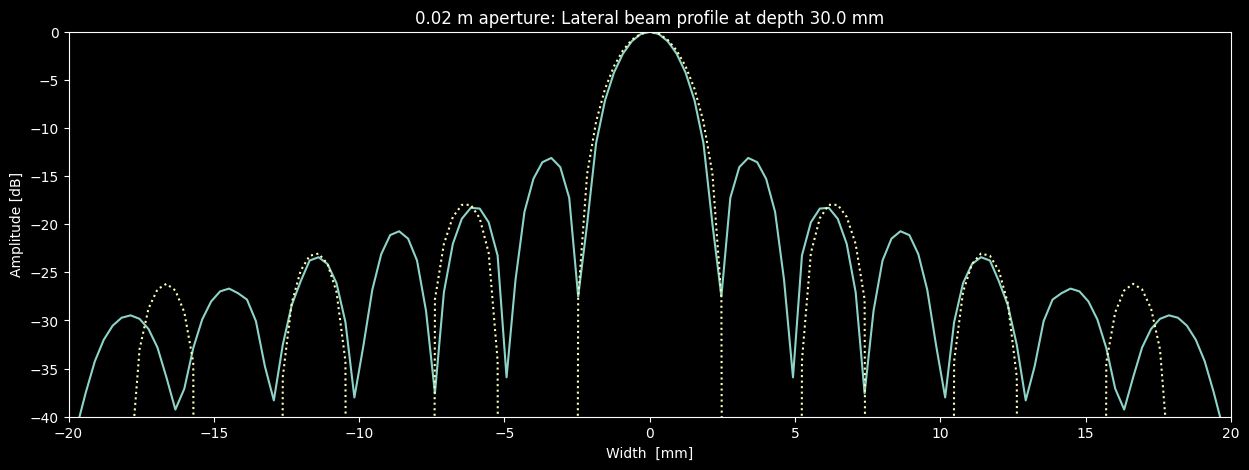

In [392]:
plt.clf()
plt.figure(figsize=(15,5))
plt.style.use('dark_background')
plt.plot(x_mm,beam_profile_p)
plt.plot(x_mm,theoretical_beam_profile_dB, linestyle="dotted")
plt.title(f'{aperture} m aperture: Lateral beam profile at depth {given_depth*1e3} mm')
plt.xlabel("Width  [mm]")
plt.ylabel("Amplitude [dB]")
plt.xlim(-20,20)
plt.ylim(-40,0)
plt.show()

Compares well, but the practical has double the sidelobes, which compared to exercise 4 makes sense. 

In [393]:
weight = np.sinc(0.5*aperture*kgrid.y_vec / (wavelength(source_f0, c0)*focal_point_distance))**2

window = np.bartlett(51)

In [394]:
source_cycles = 100
delayMap = shift(timeDelays,(1/kgrid.dt))
source, sensor, medium = run_setup(delayMap, Triangwindow=True)
sensor_data = run_simulation()


┌───────────────────────────────────────────────────────────────┐
│                   kspaceFirstOrder-OMP v1.3                   │
├───────────────────────────────────────────────────────────────┤
│ Reading simulation configuration:                        Done │
│ Number of CPU threads:                                      1 │
│ Processor name:                                               │
├───────────────────────────────────────────────────────────────┤
│                      Simulation details                       │
├───────────────────────────────────────────────────────────────┤
│ Domain dimensions:                                  162 x 162 │
│ Medium type:                                               2D │
│ Simulation time steps:                                   1839 │
├───────────────────────────────────────────────────────────────┤
│                        Initialization                         │
├───────────────────────────────────────────────────────────────┤
│ Memory a

In [395]:
p_field = np.reshape(sensor_data["p"], (kgrid.Nt, Nx, Ny), order="F")   # Stored in Fortran ordering for some reason
p_max_field = np.reshape(sensor_data['p_max'], (Nx, Ny), order="F")

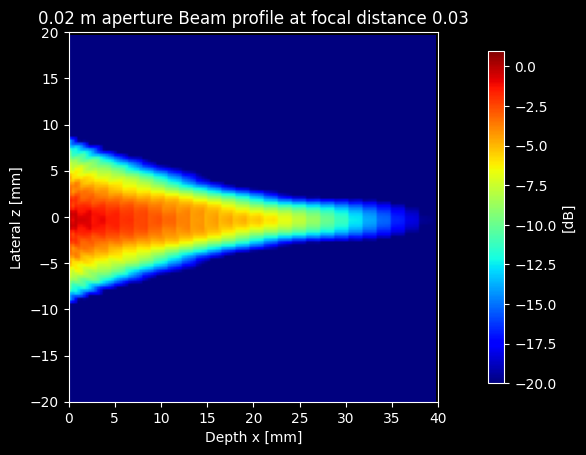

In [397]:
# Normalize frames based on the maximum value over all frames
p_max = np.abs(p_max_field)
p_max /= np.max(p_max)
p_max_db = in_dB(p_max)

cmap = 'jet'

plt.figure()
im1 = plt.imshow(p_max_db, cmap=cmap, vmin=-20, vmax=1, extent=extent)
plt.title(f'{aperture} m aperture Beam profile at focal distance {focal_point_distance}')
plt.xlabel("Depth x [mm]")
plt.ylabel("Lateral z [mm]")
plt.xlim(0,40)
plt.ylim(-20,20)
plt.colorbar(im1, pad=0.1, shrink=0.9, label="[dB]")
plt.show()